**Examinationsarbete i Deep Learning**

**Project $alpha$**

Målbild:

- Designa och träna Convolutional Neural Networks (CNNs) från grunden, för att klassificera bilder i CIFAR-10 datasetet.

Generella och specifika kraven för betygsgränser beskrivs längre ner.

---

**Dataset, CIFAR-10**

- **Antal bilder:** 60,000 (32x32 pixlar, färgbilder).
- **Klasser:** 10 klasser (t.ex. flygplan, bil, fågel, katt).
- **Uppdelning:**
  - Träning: 50,000 bilder.
  - Test: 10,000 bilder.

**Evalueringskrav**

Datasetet ska laddas in från PyTorchs `torchvision` bibliotek, och tillhörande testset ska användas för evaluering. 

---

**Project $alpha$**


Här ska ni designa och träna Convolutional Neural Networks (CNNs) från grunden, i syfte att klassificera bilder i CIFAR-10-datasetet. Modellerna som tränas för att uppnå kraven för **G** samt **VG** nedan får *ej* vara pretrained. 

**Krav för G:**
- Mellan **75-80% accuracy** på test-settet.
- Designa, träna och evaluera minst **tre olika CNN-arkitekturer**.
- Prestandan av varje färdigtränad modell ska vara tydlig, och även loss-kurvor ska plottas - följt av en kortfattad analys av dessa.
- I varje CNN-klass ska, i `forward`-metoden, **storleken på input och output för varje operation** skrivas ut som en kommentar.
- Gör dessutom en **kvalitativ analys** av dina modellers prestanda (vilka klasser presteras bra på, och vilka dåligt) - och varför, om möjligt.

**Krav för VG:**

- Uppnår kraven för **G**, och når **85%+ accuracy** på test-settet.
- Ni använder dessutom flertalet metoder under träningen som ni själva läst på och lärt er om, exempelvis via litteraturhänvisningen.
    - samtliga metoder, utöver de vi gått igenom i klassen, som ni väljer att använda ska ni i ett särskilt stycke i er notebook, förklara (så gott ni kan) 
    samt ge referenser till.
- Ni ska även att utföra en ordentlig error analysis, på er bäst presterade modell.

**Krav för Guldstjärna:**

- Uppnår kraven för **VG**, och når **90%+ accuracy** på test-settet.
- Hittar även en lämplig pretrained modell, anpassar den för datasetet samt uppnår **95%+** accuracy på test-settet. 





Var kreativa med era arkitekturer. Ni behöver exempelvis inte begränsa er till det 'normala' convolutional block som vi 
lärde oss under föreläsningarna (dvs conv layer + relu följt av pooling), utan det kan se annorlunda ut. Se litteraturhänvisningarna för inspiration från kända CNN-arkitekturer som ex. AlexNet, VGG, ResNet etc. 

Utöver det finns det andra knep man kan integrera in i sin CNN som empiriskt visat förbättra prestanda. Exempelvis:

- Batch Normalization
- Data Augmentation
- Alternativa Optimizers (ex Adam, RMSprop)
- Learning Rate Scheduling

Ni har friheten att själva söka information om dessa och hur de implementeras i PyTorch, för att sedan nyttja dem i ert projekt.

**Pre-trained models & Transfer Learning**

Kraven för **G** och **VG** utgår utifrån att man tränat modeller från grunden. För Guldstjärna ska ni som sagt även nyttja transfer learning med en redan färdigtränad modell. Det räcker med en sådan, om ni lyckas uppnå 95% accuracy på test-settet.

Det kan dock vara rätt beräkningstungt.

Ni lämnar in en notebook fil som innehåller allt arbete. Notebooken ska dessutom sparas med alla outputen kvarstående! 

Mao ska jag bara kunna bläddra igenom er notebook för att se allt arbete och alla output, utan att för den delen köra koden själv.

Spara notebook:en med namnet **{namn}\_{efternamn}\_{alpha}.ipynb**, och skicka därefter in via elevera-portalen.

---

**Literaturlista**

Följande research ger både en inblick i historiken av CNN-arkitekturers utveckling, och kan ge idéer om nyttiga idéer i era egna projekt:

* [__LeNet-5__](http://yann.lecun.com/exdb/lenet/). Grundläggande arbete som introducer konceptet med Convolutional Neural Networks.
* [__AlexNet__](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf). Vann ImageNet-tävlingen 2012, genom att bland annat introducera "ReLU".
* [__VGGNet__](https://arxiv.org/abs/1409.1556).
* [__GoogLeNet__](https://arxiv.org/abs/1409.4842). Introducerade "Inception"-modulen (aka "bottle-neck layer").
* [__ResNet__](http://openaccess.thecvf.com/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf). Introducerar "skip connections" som hjälper djupa nätverk att lära sig. 
* [__EfficientNet__](https://arxiv.org/abs/1905.11946)

Ni kan givetvis lära er mer om dessa koncept genom att söka efter alternativa källor också.





---

**Inlämning**



In [1]:
#Import libraries
import torch
from torchvision import models
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import random_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

---
## **Data förberedning**

In [2]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load CIFAR-10 dataset
train_base = datasets.CIFAR10(root='./data', train=True, download=True)
test_base = datasets.CIFAR10(root='./data', train=False, download=True)

# Split train into train and validation
indices = list(range(50000))
train_idx, val_idx = indices[:45000], indices[45000:]

# Custom dataset to apply transforms on subsets
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices=None, transform=None):
        self.dataset = dataset
        self.indices = indices if indices is not None else range(len(dataset))
        self.transform = transform
    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.indices)

train_data = ApplyTransform(train_base, train_idx, train_transform)
val_data = ApplyTransform(train_base, val_idx, test_transform)
test_data = ApplyTransform(test_base, None, test_transform)

# DataLoaders
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

/Users/wijdancederlid/Desktop/deep_ML/deeplearning/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


---
## **Definera träningsfunktion**

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu') # Use MPS if available otherwise CPU
    model.to(device)
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            scheduler.step()
            running_train_loss += loss.item()
        
        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_train_loss = running_train_loss / len(train_loader)
        avg_val_loss = running_val_loss / len(val_loader)
        val_acc = 100 * correct / total if total > 0 else 0

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f'Epoch [{epoch+1}/{epochs}] - '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Val Loss: {avg_val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}% - '
              f'LR: {scheduler.get_last_lr()[0]:.6f}')
              
    print("Training completed!")
    return train_losses, val_losses, val_accuracies

---
## **Modell nr 1**

In [4]:
# Define CNN model number 1
class CNN1(nn.Module):
    def __init__(self):
        super(CNN1, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            #Input: [3, 32, 32]
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding='same'),  
            nn.BatchNorm2d(32), 
            nn.ReLU(),
            #Output: [32, 32, 32]
            nn.MaxPool2d(2, 2), 
            #Output: [32, 16, 16]
            
            #Input: [32, 16, 16]
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            #Output: [64, 16, 16]
            nn.MaxPool2d(2, 2)  
            #Output: [64, 8, 8]
        )
        
        # Classifier layers
        self.classifier = nn.Sequential(
            nn.Flatten(), 
            #Output size: 64*8*8 = 4096
            nn.Linear(in_features=64 * 8 * 8, out_features=256),
            nn.ReLU(),
            #output size: 256
            nn.Dropout(0.3),
            #Input size: 256
            nn.Linear(in_features=256, out_features=10)
            #Output size: 10
        )

    def forward(self, x):
        #Input shape: [3, 32, 32]
        x = self.features(x)
        #Shape after features: [64, 8, 8]
        x = self.classifier(x)
        #Final output shape: [10]
        return x



In [5]:
model1 = CNN1()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Loss function for multi-class classification
optimizer1 = optim.AdamW(model1.parameters(), lr=0.001, weight_decay=1e-4) 
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer1, 
    max_lr=0.012, 
    steps_per_epoch=len(train_dataloader), 
    epochs=20, 
    pct_start=0.3, 
    anneal_strategy='cos'
)
print("Training Model 1...")
train_loss, val_loss, val_acc = train_model(model1, train_dataloader, val_dataloader, criterion, optimizer1, scheduler, epochs=20) # Trains model for 20 epochs

Training Model 1...
Epoch [1/20] - Train Loss: 1.7734, Val Loss: 1.5225, Val Acc: 52.44% - LR: 0.001252
Epoch [2/20] - Train Loss: 1.6395, Val Loss: 1.4623, Val Acc: 56.70% - LR: 0.003361
Epoch [3/20] - Train Loss: 1.5601, Val Loss: 1.3475, Val Acc: 63.16% - LR: 0.006242
Epoch [4/20] - Train Loss: 1.4950, Val Loss: 1.3481, Val Acc: 64.36% - LR: 0.009122
Epoch [5/20] - Train Loss: 1.4843, Val Loss: 1.3139, Val Acc: 66.00% - LR: 0.011230
Epoch [6/20] - Train Loss: 1.4687, Val Loss: 1.3097, Val Acc: 66.62% - LR: 0.012000
Epoch [7/20] - Train Loss: 1.4387, Val Loss: 1.2815, Val Acc: 67.72% - LR: 0.011849
Epoch [8/20] - Train Loss: 1.4279, Val Loss: 1.2935, Val Acc: 67.40% - LR: 0.011405
Epoch [9/20] - Train Loss: 1.4056, Val Loss: 1.2336, Val Acc: 69.86% - LR: 0.010690
Epoch [10/20] - Train Loss: 1.3855, Val Loss: 1.2414, Val Acc: 69.62% - LR: 0.009739
Epoch [11/20] - Train Loss: 1.3446, Val Loss: 1.2571, Val Acc: 67.50% - LR: 0.008602
Epoch [12/20] - Train Loss: 1.3262, Val Loss: 1.1882, 

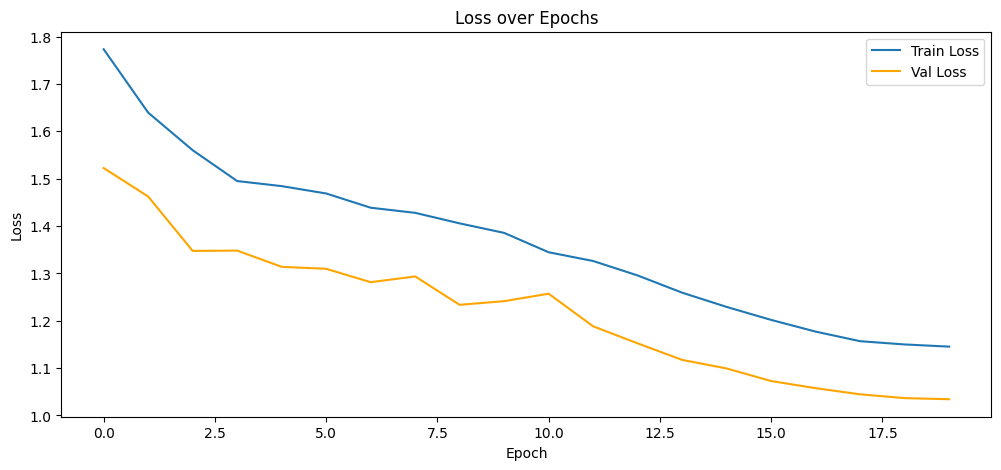

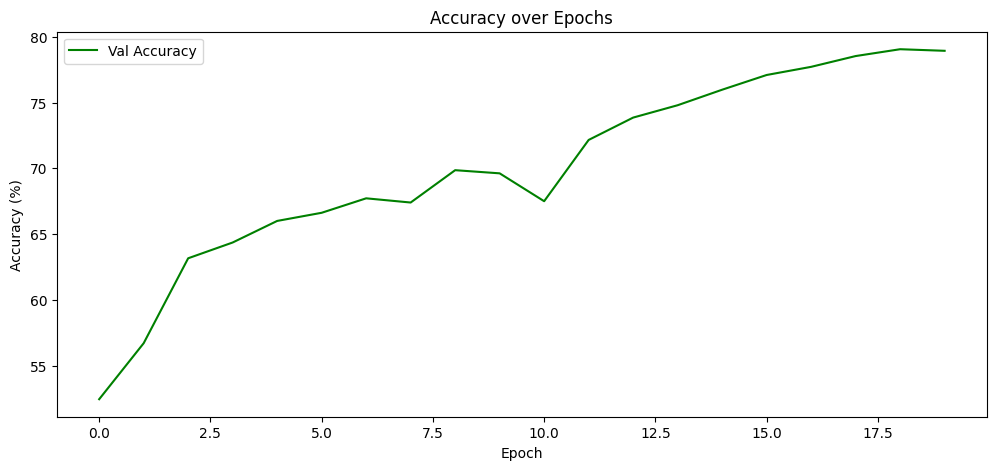

In [6]:

# 1. Plot Loss Curves 
plt.figure(figsize=(12, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss', color='orange') 
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# 2. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_acc, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

Generating confusion matrix data...


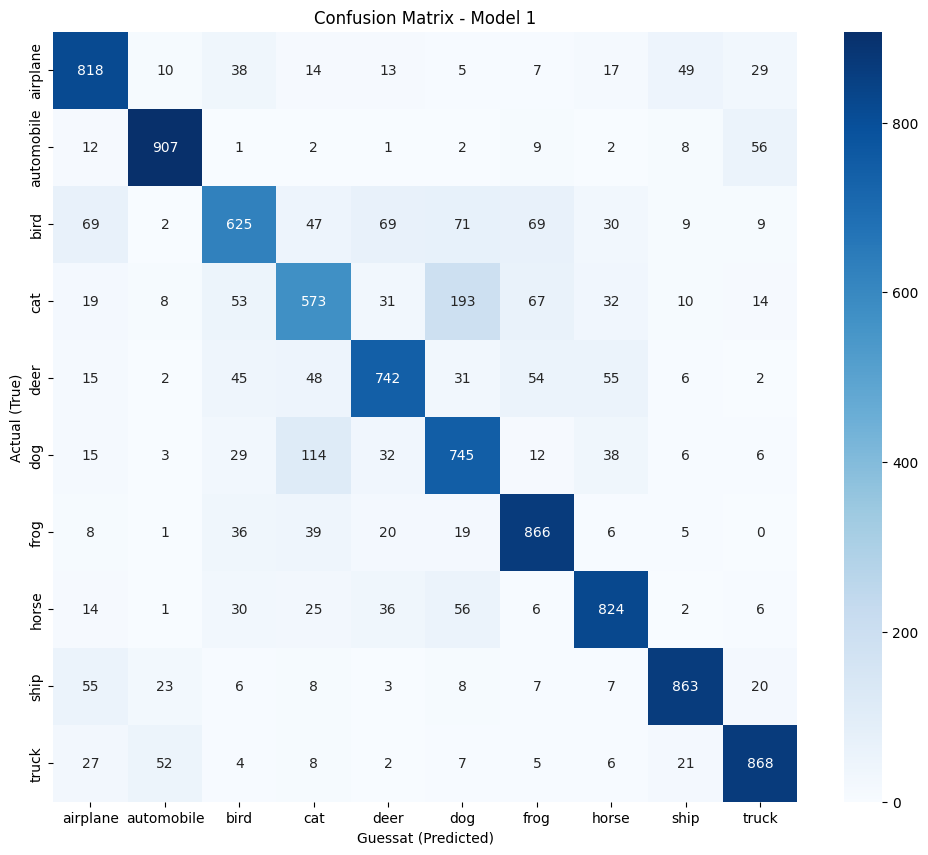

In [7]:
def plot_confusion_matrix(model, test_loader, class_names):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval()
    all_preds = []
    all_labels = []
    
    print("Generating confusion matrix data...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Guessat (Predicted)')
    plt.ylabel('Actual (True)')
    plt.title('Confusion Matrix - Model 1')
    plt.show()

plot_confusion_matrix(model1, test_dataloader, test_base.classes) # test_base.classes contains the class names

### **Analys modell nr 1**

Det är en tydlig nedgång på losskurvorna för både min träning- och valideringsloss. Träning- och valideringslossen fortsätter att sjunka stabilt vilket tyder på att modellen lär sig istället för att memorisera dvs "overfitt". Man kan även se att valderingsloss kurvan ökar upp och sen ner två gånger vilket kan ske när modellen försöker hitta rätt learningrate. Det som är spännande här är att valideringsloss är lägre än träningsloss vilket är resultat av att jag har använt data augmentation, det gör att modellen får svårare bilder under träning men inte under validering.
Fortsatt träning kan dock leda till overfitt dvs att modellen memorerar istället för att lära sig.

Validerings accuracy är över 78%  nästan 79% och även test accuracy är över 78%, en bra indikation på att modellen inte memorerat.

**Obs. testerna finns i celler längre ner för alla modeller.**

### **Kvalitativ analys av modell 1**

Modellen presterar bäst på Automobile och Truck. Anledningen är troligen att dessa klasser har mer tydliga särdrag såsom skarpa kanter och distinkta geometrisk form. Frog och Ship uppvisar hög nogrannhet då grodor har ofta unik färgskala och textur(inte päls) vilket gör de lättare att separera från pälsdjur, medan Ship har oftast blå bakgrund och unik form. 

Klasserna modellen har svårast för är Cat och Bird. Särkilt förvirring sker mellan katt och hund. Detta beror troligen sannolikt på att de delar liknande särdrag som päls, nos och öron. Modellen har en enkel arkitektur som inte är säskilt bred eller djup, vilket att den inte lyckas fånga de finare detaljer som krävs för att skilja dessa komplexa djurklasser åt. Den identifierar främst grundläggande mönster snarare än fina detaljer. Med tanke på hur enkel modellen är och att endast tränats i 20 epoker, presterar den dock förhållandevis väl på att separera huvudsakliga kategorierna. 


---
## **Modell nr 2**

In [8]:
# Define CNN model number 2
class CNN2(nn.Module):
    def __init__(self):
        super(CNN2, self).__init__()
     
        #Feature extraction layers
        self.features = nn.Sequential(
            #Input: [3, 32, 32]
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64), 
            nn.ReLU(),
            #Output: [64, 32, 32]
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            #Output: [64, 32, 32]
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            #Output after maxpool: [64, 16, 16]
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            #Output: [128, 16, 16]
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            #Output: [128, 16, 16]
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            #Output after maxpool: [128, 8, 8]
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            #Output: [256, 8, 8]
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            #Output: [256, 8, 8]
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3)
            #Output after maxpool: [256, 4, 4]
        )
        
        # Classifier layers
        self.classifier = nn.Sequential(
            nn.Flatten(), 
            #Output size: 256*4*4 = 4096
            nn.Linear(in_features=256 * 4 * 4, out_features=512),
            nn.ReLU(),
            #Output size: 512
            nn.Dropout(0.3),
            nn.Linear(in_features=512, out_features=10) 
            #Output size: 10
        )

    def forward(self, x):
        #Input shape: [3, 32, 32]
        x = self.features(x)
        #Shape after features: [256, 4, 4]
        x = self.classifier(x)
        #Final output shape: [10]
        return x



In [9]:
model2 = CNN2()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 
optimizer2 = optim.AdamW(model2.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer2, 
    max_lr=0.012, 
    steps_per_epoch=len(train_dataloader), 
    epochs=20, 
    pct_start=0.3, 
    anneal_strategy='cos'
)
print("Training Model 2...")
train_loss2, val_loss2, val_acc2 = train_model(model2, train_dataloader, val_dataloader, criterion, optimizer2, scheduler, epochs=20)

Training Model 2...
Epoch [1/20] - Train Loss: 1.7973, Val Loss: 1.5740, Val Acc: 50.18% - LR: 0.001252
Epoch [2/20] - Train Loss: 1.5424, Val Loss: 1.4841, Val Acc: 55.94% - LR: 0.003361
Epoch [3/20] - Train Loss: 1.4026, Val Loss: 1.2374, Val Acc: 68.72% - LR: 0.006242
Epoch [4/20] - Train Loss: 1.3215, Val Loss: 1.1716, Val Acc: 73.34% - LR: 0.009122
Epoch [5/20] - Train Loss: 1.2727, Val Loss: 1.2569, Val Acc: 70.70% - LR: 0.011230
Epoch [6/20] - Train Loss: 1.2498, Val Loss: 1.2016, Val Acc: 70.98% - LR: 0.012000
Epoch [7/20] - Train Loss: 1.1948, Val Loss: 1.0826, Val Acc: 76.20% - LR: 0.011849
Epoch [8/20] - Train Loss: 1.1553, Val Loss: 1.0253, Val Acc: 79.50% - LR: 0.011405
Epoch [9/20] - Train Loss: 1.1202, Val Loss: 0.9970, Val Acc: 80.04% - LR: 0.010690
Epoch [10/20] - Train Loss: 1.0840, Val Loss: 0.9742, Val Acc: 81.38% - LR: 0.009739
Epoch [11/20] - Train Loss: 1.0542, Val Loss: 0.9685, Val Acc: 80.98% - LR: 0.008602
Epoch [12/20] - Train Loss: 1.0212, Val Loss: 0.9893, 

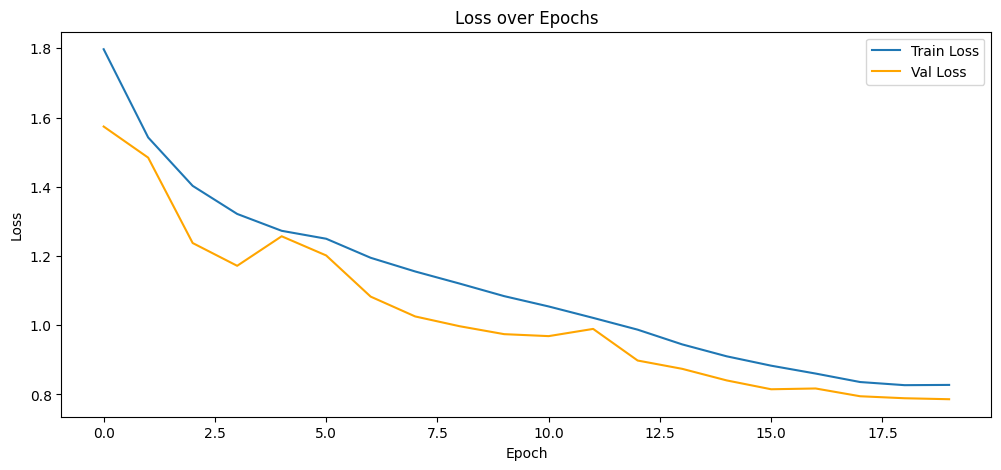

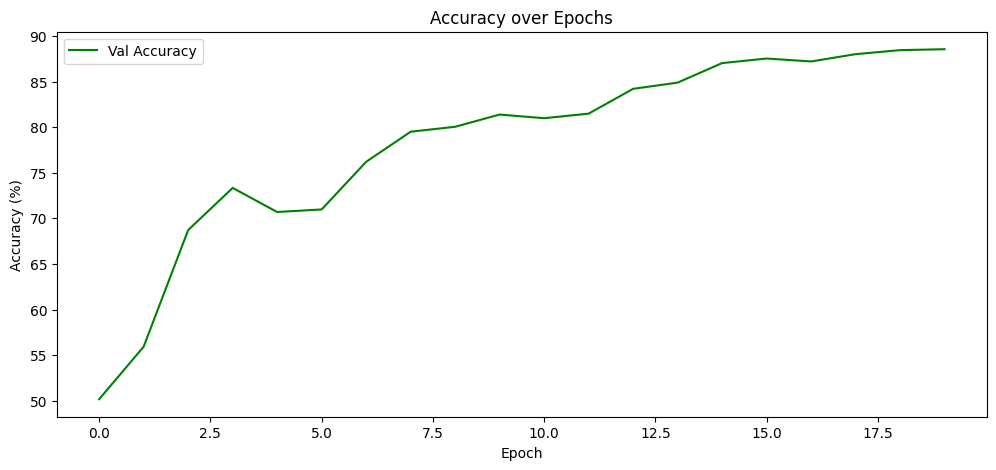

In [10]:

# 1. Plot Loss Curves 
plt.figure(figsize=(12, 5))
plt.plot(train_loss2, label='Train Loss')
plt.plot(val_loss2, label='Val Loss', color='orange') 
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# 2. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_acc2, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

Generating confusion matrix data...


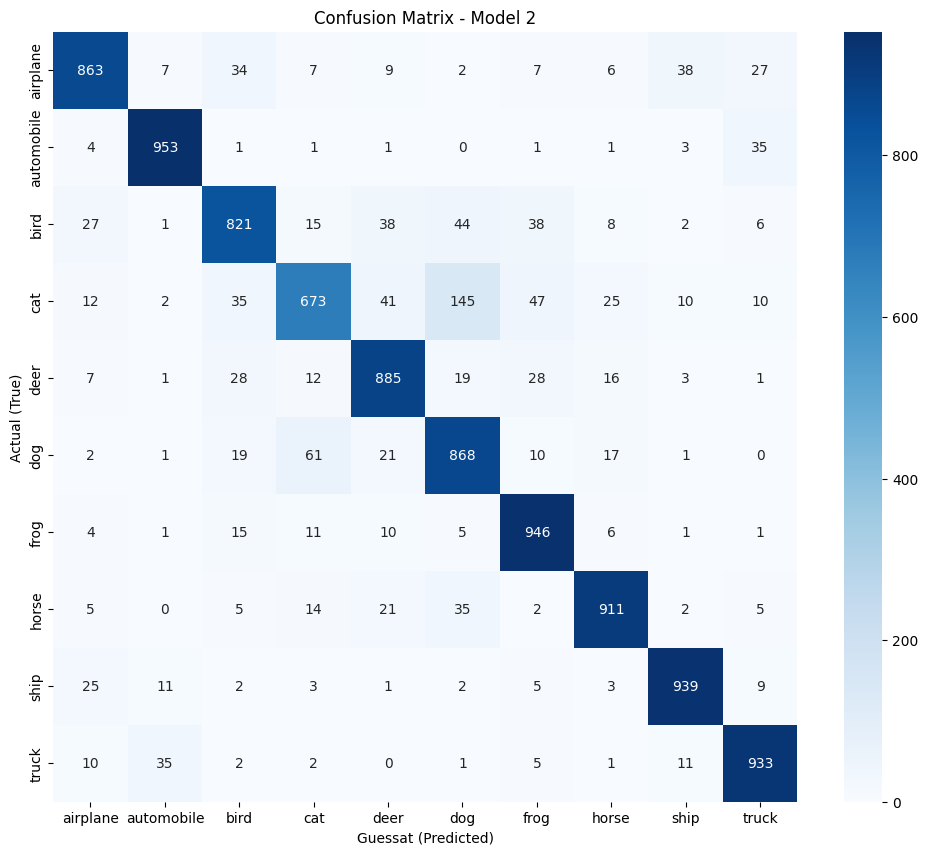

In [11]:
def plot_confusion_matrix(model, test_loader, class_names):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval()
    all_preds = []
    all_labels = []
    
    print("Generating confusion matrix data...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Guessat (Predicted)')
    plt.ylabel('Actual (True)')
    plt.title('Confusion Matrix - Model 2')
    plt.show()

plot_confusion_matrix(model2, test_dataloader, test_base.classes) # test_base.classes contains the class names

### **Analys modell nr 2**

Min andra modell visar att det är en mer komplex ariktektur som kan hitta fler samband och detaljer i bilderna vilket man kan se på den snabbare nedgången i kurvorna. Även här kan man se att valideringslossen är lägre än träningslossen pga data augmentation och droupout, men kurvorna ligger tätare ihop och det tyder på att modellen är bättre på att generalisera. Ingen tydan på overfitting här och man skulle kunna träna modellen ytterligare. Denna modell är betydligt bättre än första modellen.

Validerings accuracy är över 88% och test accuracy är över 87% nästan 88%, även här visar det att modellen inte overfittar. 

### **Kvalitativ analys av modell 2**

Modellen 2 presterar betydligt bättre än modell 1 tack vare en mer komplex arkitektur, men har fortfarande kvar liknande utmaningar som förra modellen. Den presterar allra bäst på Automobile, Frog, Ship och Truck. Anledningen till att fordon går så bra, precis som tidigare, deras skarpa kanter och tydliga geometriska former som gör dem lätta för modellen att identifiera. Grodor sticker också ut med sin unika färg och textur vilket effektivt skiljer de från pälsdjur. 

Cat är fortfarande den klass som modellen har svårast för, följt av Bird. Även om modellen har förbättrats avsevärt jämfört med första modellen, kvarstår förvirring mellan katt och hund. De liknande särdragen hos dessa djur, i kombination med låg upplösning på bilder, gör det svårt för även en mer avancerad modell att dra en gräns. 

---
## Modell nr 3

In [12]:
# Define CNN model number 3
class CNN3(nn.Module):
    def __init__(self):
        super(CNN3, self).__init__()
        
        # FEATURE EXTRACTION 
        self.features = nn.Sequential(
            #Input: [3, 32, 32]
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64), 
            nn.ReLU(),
            #Output: [64, 32, 32]
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            #Output: [64, 32, 32]
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            #Output after maxpool: [64, 16, 16]
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            #Output: [128, 16, 16]
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            #Output: [128, 16, 16]
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            #Output after maxpool: [128, 8, 8]
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            #Output: [256, 8, 8]
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            #Output: [256, 8, 8]
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3),
            #Output after maxpool: [256, 4, 4]

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding='same'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            #Output: [512, 4, 4]
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            #Output: [512, 4, 4]
            nn.AdaptiveAvgPool2d(1) 
            #Output: [512, 1, 1]
        )
        
        # CLASSIFIER LAYERS
        self.classifier = nn.Sequential(
            nn.Flatten(),
            #Output size: 512*1*1 = 512
            nn.Linear(in_features=512, out_features= 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            #Output size: 512

            nn.Linear(in_features=512, out_features=10) 
            #Output size: 10
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [13]:
model3 = CNN3()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 
optimizer3 = optim.AdamW(model3.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer3, 
    max_lr=0.005, 
    steps_per_epoch=len(train_dataloader), 
    epochs=30, 
    pct_start=0.3, 
    anneal_strategy='cos'
)
print("Training Model 3...")
train_loss3, val_loss3, val_acc3 = train_model(model3, train_dataloader, val_dataloader, criterion, optimizer3, scheduler, epochs=30)

Training Model 3...
Epoch [1/30] - Train Loss: 1.6595, Val Loss: 1.4894, Val Acc: 55.84% - LR: 0.000345
Epoch [2/30] - Train Loss: 1.3891, Val Loss: 1.3288, Val Acc: 65.06% - LR: 0.000762
Epoch [3/30] - Train Loss: 1.2655, Val Loss: 1.1935, Val Acc: 70.92% - LR: 0.001400
Epoch [4/30] - Train Loss: 1.2048, Val Loss: 1.1000, Val Acc: 74.72% - LR: 0.002184
Epoch [5/30] - Train Loss: 1.1464, Val Loss: 1.1409, Val Acc: 73.72% - LR: 0.003017
Epoch [6/30] - Train Loss: 1.0977, Val Loss: 1.0341, Val Acc: 77.72% - LR: 0.003801
Epoch [7/30] - Train Loss: 1.0442, Val Loss: 0.9720, Val Acc: 80.76% - LR: 0.004439
Epoch [8/30] - Train Loss: 1.0172, Val Loss: 0.9945, Val Acc: 78.96% - LR: 0.004856
Epoch [9/30] - Train Loss: 0.9902, Val Loss: 0.9282, Val Acc: 82.82% - LR: 0.005000
Epoch [10/30] - Train Loss: 0.9513, Val Loss: 0.9511, Val Acc: 81.70% - LR: 0.004972
Epoch [11/30] - Train Loss: 0.9271, Val Loss: 0.8932, Val Acc: 83.52% - LR: 0.004889
Epoch [12/30] - Train Loss: 0.9029, Val Loss: 0.8383, 

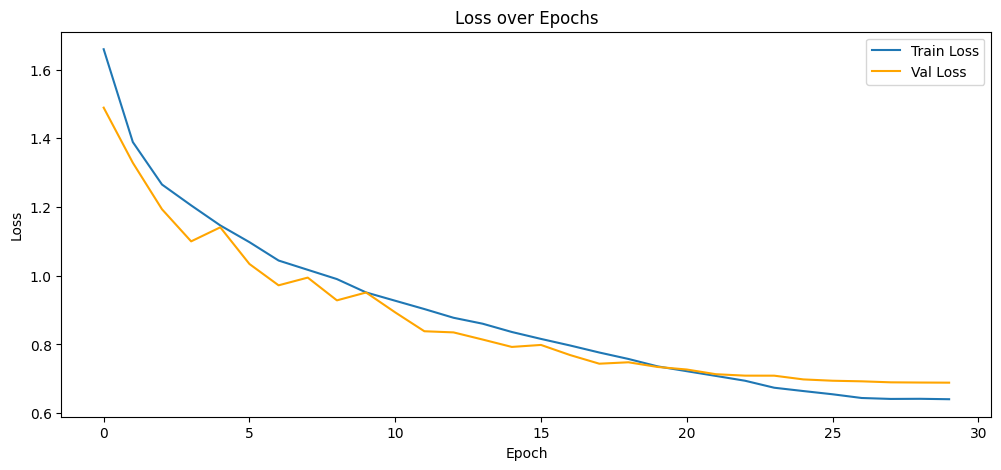

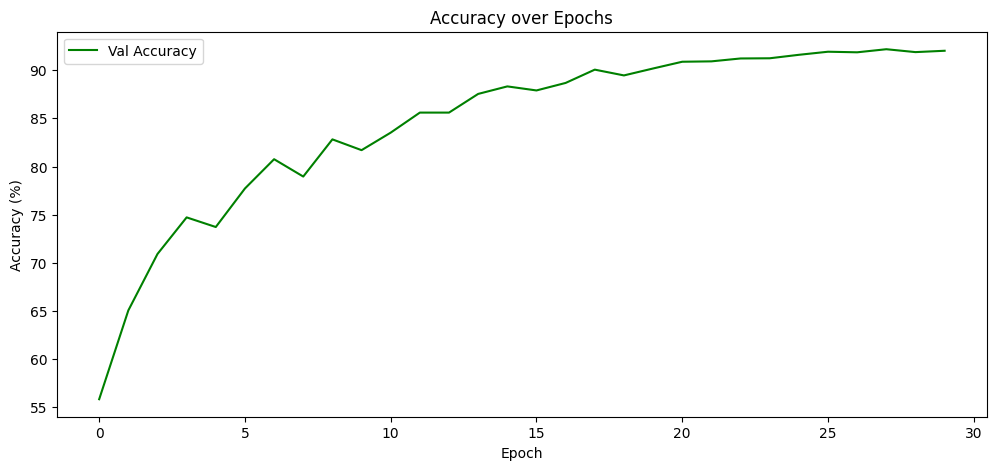

In [14]:

# 1. Plot Loss Curves 
plt.figure(figsize=(12, 5))
plt.plot(train_loss3, label='Train Loss')
plt.plot(val_loss3, label='Val Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# 2. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_acc3, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

### **Analys modell nr 3**

Man kan se på loss-kurvorna att modellen är ännu mer komplex med fler lager och filter då kurvorna sjunker väldigt jämnt och snabbare. Valideringskurvan är mindre spretig på slutet och det är resultatet av att jag använde ApaptiveAvgPool2d() som hjälper modellen att regualrisera. Det är inte ett stort gap mellan kurvorna här heller och visar återigen att modellen lär sig och generliserar bra, skillnaden är på denna och förra modell är att kurvorna håller sig tät ihop under alla epoker. Det finns en risk för overfit om man fortsätter träna. 

Validerings accuracy är 92% och test accuracy är över 91%, bra modell utan overfit.

**Obs. En ordentlig analys finns längre ner för denna.**


---
## **Evaluera på test-set**

In [15]:
def evaluate_model(model, test_loader):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval() 
    
    correct = 0
    total = 0
    
    with torch.no_grad(): 
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy

In [16]:

print("Evaluating Model 1 on test set...")
test_acc1 = evaluate_model(model1, test_dataloader)

print("Evaluating Model 2 on test set...")
test_acc2 = evaluate_model(model2, test_dataloader)

print("Evaluating Model 3 on test set...")
test_acc3 = evaluate_model(model3, test_dataloader)

Evaluating Model 1 on test set...
Test Accuracy: 78.31%
Evaluating Model 2 on test set...
Test Accuracy: 87.92%
Evaluating Model 3 on test set...
Test Accuracy: 91.59%


In [17]:
test_accuracies = []

print("Evaluating all models on test set...")
test_accuracies.append(evaluate_model(model1, test_dataloader))
test_accuracies.append(evaluate_model(model2, test_dataloader))
test_accuracies.append(evaluate_model(model3, test_dataloader))

Evaluating all models on test set...
Test Accuracy: 78.31%
Test Accuracy: 87.92%
Test Accuracy: 91.59%


---
## **Förklaring av hjälpmetoderna jag har använt**

**Data Augmentation**
Denna metod har jag använt för att förbättra modellens generaliseringsförmåga och förhindra overfitting. Genom att augmentera bilder kan man få modellen att lära sig samband och mönster istället för att memorera. 
- `RandomHorizontalFlip()`: Slumpmässigt spegelvänder bilder, det lär modellen att hitta samband.
- `RandomCrop(32, padding=4)`: Skär ut och "paddar" bilderna slumpmässigt. Lär modellen att hitta särdrag oavsett vart på bilden de befinner sig.
- `Normalize()`: Jag användar CIFAR-10s egna värden för att normalisera datat.

__[Länk!Hittat infon här på Pytorch](https://docs.pytorch.org/vision/0.21/transforms.html)__

**Batch Normalization (`BatchNorm2d`)**
Används för att normalisera aktiveringen i varje batch efter varje lager. Det stabilserar inlärningsprocessen genom att värdena normaliseras alltså inte ha för stora eller för små siffror. Det påskyndar träning och hjälper lagren att hitta rätt svar. Det minskar/motverkar `Internal covariate shift´ dvs att inmatningsfördelningen till lager ändras eftersom lagret tidigare uppdateras. 

__[Länk!Hittat infon här på geeksforgeeks](https://www.geeksforgeeks.org/computer-vision/what-is-batch-normalization-in-cnn/)__

**AdamW Optimizer**
En optimeringsalgoritm som används för att hjälpa till med generaliseringen och förhindrar vikter att blir för stora. Det är en förbättrad Adam då den separerad regulariseringen (weight_decay eller L2) från gradienten, detta gör att regulariseringen blir konsekvent, stabilare träning och bättre generalisering.

weight_decay hindrar vikter från att bli för stora.

__[Länk!Hittat infon här på geeksforgeeks](https://www.geeksforgeeks.org/deep-learning/why-is-adamw-often-superior-to-adam-with-l2-regularization-in-practice/)__

**OneCycleLR Scheduler**
Ändrar learning rate under träningen, börjar med lågt värde sedan ökar snabbt till `max_lr` och sedan sänks långsamt till ett väldigt lågt värde. Hälper generalisering, snabbare konvergens och förkortar träningen.

- `steps_per_epoch = len(train_dataloader)`: Uppdaterar learning rate vid varje batch istllet för varje epok.
- `pct_start=0.3`: 30% av epokernas learning rate ökar, 70% minskas.
- `anneal_strategy='cos'`: Använder cosine annealing för en mjukare minskning av learning rate, alltså ger en rundad nedgång, bra för stabilitet.

__[Länk!Hittat infon här på Medium](https://medium.com/@g.martino8/one-cycle-lr-scheduler-a-simple-guide-c3aa9c4cbd9f)__


**Label Smoothing (`label_smoothing=0.1`)**
En regulariseringsteknink för klassificering som gör modellen mindre självsäker genom att "sprida ut" sannolikheterna alltså istället 1.0 på rätt klass så blir det 0.9. Det hjälper modellen att generalisera bättre, robust mot felmärkta klasser "brus" och förhindrar overfitting.

__[Länk!Hittat infon här på towards data science](https://towardsdatascience.com/what-is-label-smoothing-108debd7ef06/)__



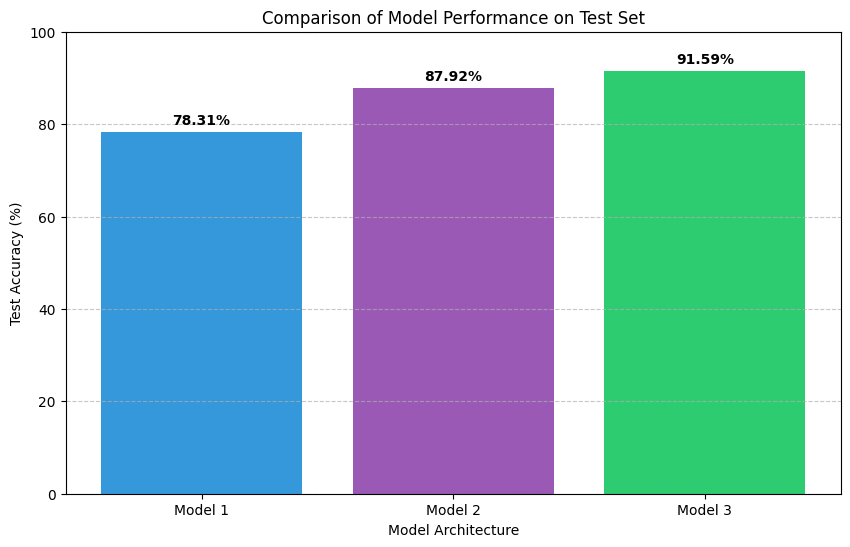

In [18]:
def plot_model_comparison(test_accs):
    models = ['Model 1', 'Model 2', 'Model 3']
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, test_accs, color=['#3498db', '#9b59b6', '#2ecc71'])
    
    plt.xlabel('Model Architecture')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Comparison of Model Performance on Test Set')
    plt.ylim(0, 100) 
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_model_comparison(test_accuracies)

---
## **Error analys**

Generating confusion matrix data...


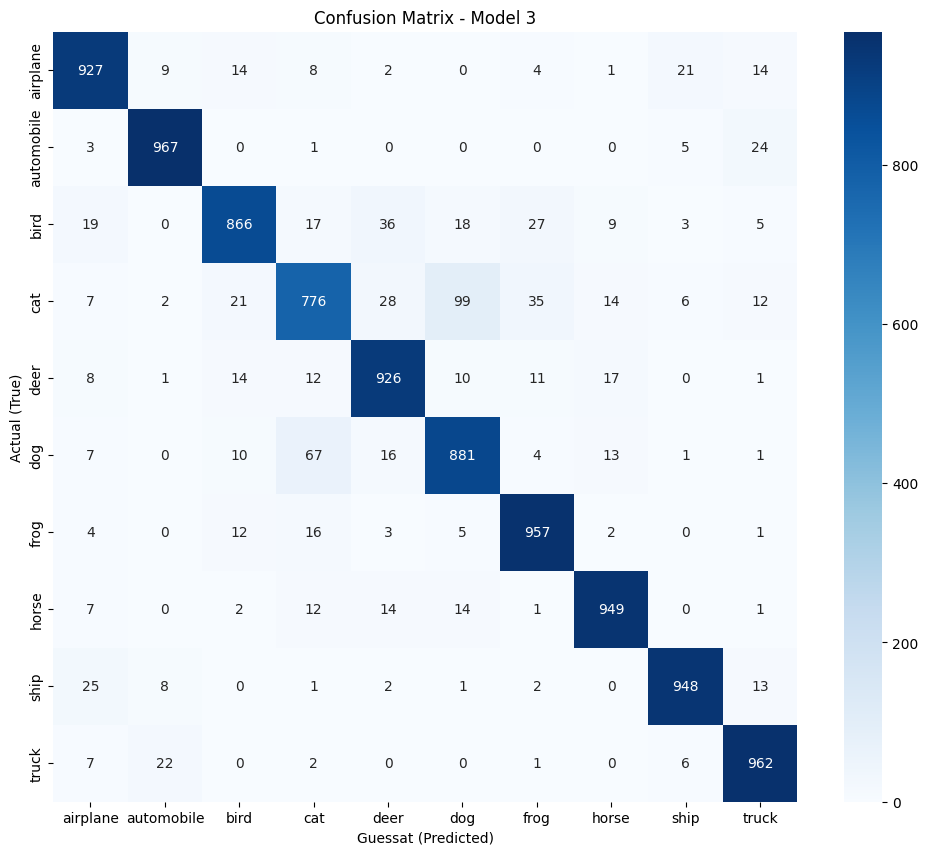

In [19]:
def plot_confusion_matrix(model, test_loader, class_names):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval()
    all_preds = []
    all_labels = []
    
    print("Generating confusion matrix data...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Guessat (Predicted)')
    plt.ylabel('Actual (True)')
    plt.title('Confusion Matrix - Model 3')
    plt.show()

plot_confusion_matrix(model3, test_dataloader, test_base.classes) # test_base.classes contains the class names

Searching for misclassified images...


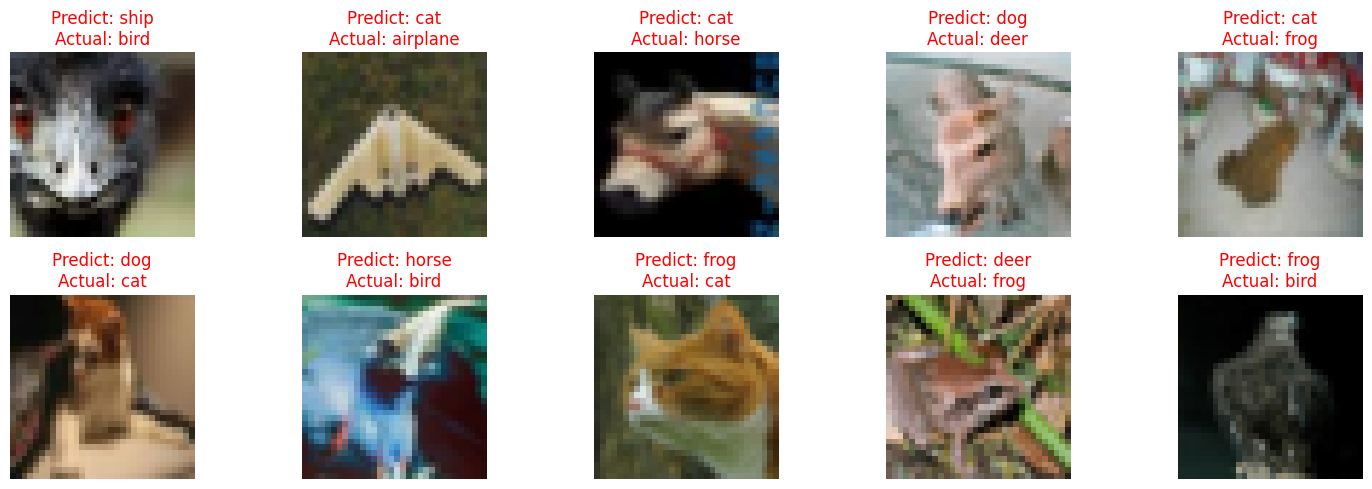

In [20]:
def plot_misclassified(model, test_loader, class_names, num_images=10):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    misclassified_images = []
    actual_labels = []
    predicted_labels = []
    
    print("Searching for misclassified images...")
    with torch.no_grad():
        for images, labels in test_loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            _, preds = torch.max(outputs, 1)
            
            #Find where predictions do not match the actual labels
            mask = (preds != labels.to(device))
            
            if mask.any():
                # Save misclassified images and their labels
                misclassified_images.extend(images[mask.cpu()])
                actual_labels.extend(labels[mask.cpu()].numpy())
                predicted_labels.extend(preds[mask.cpu()].cpu().numpy())
                
            if len(misclassified_images) >= num_images:
                break

    # Plot predicted vs actual for misclassified images
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(2, 5, i + 1)
        
        # Denormalize for correct display using same mean/std as in the transform
        img = misclassified_images[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2470, 0.2435, 0.2616])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        plt.imshow(img)
        plt.title(f"Predict: {class_names[predicted_labels[i]]}\nActual: {class_names[actual_labels[i]]}", 
                  color='red' if predicted_labels[i] != actual_labels[i] else 'green')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

plot_misclassified(model3, test_dataloader, test_base.classes)

Analyzing confident errors...


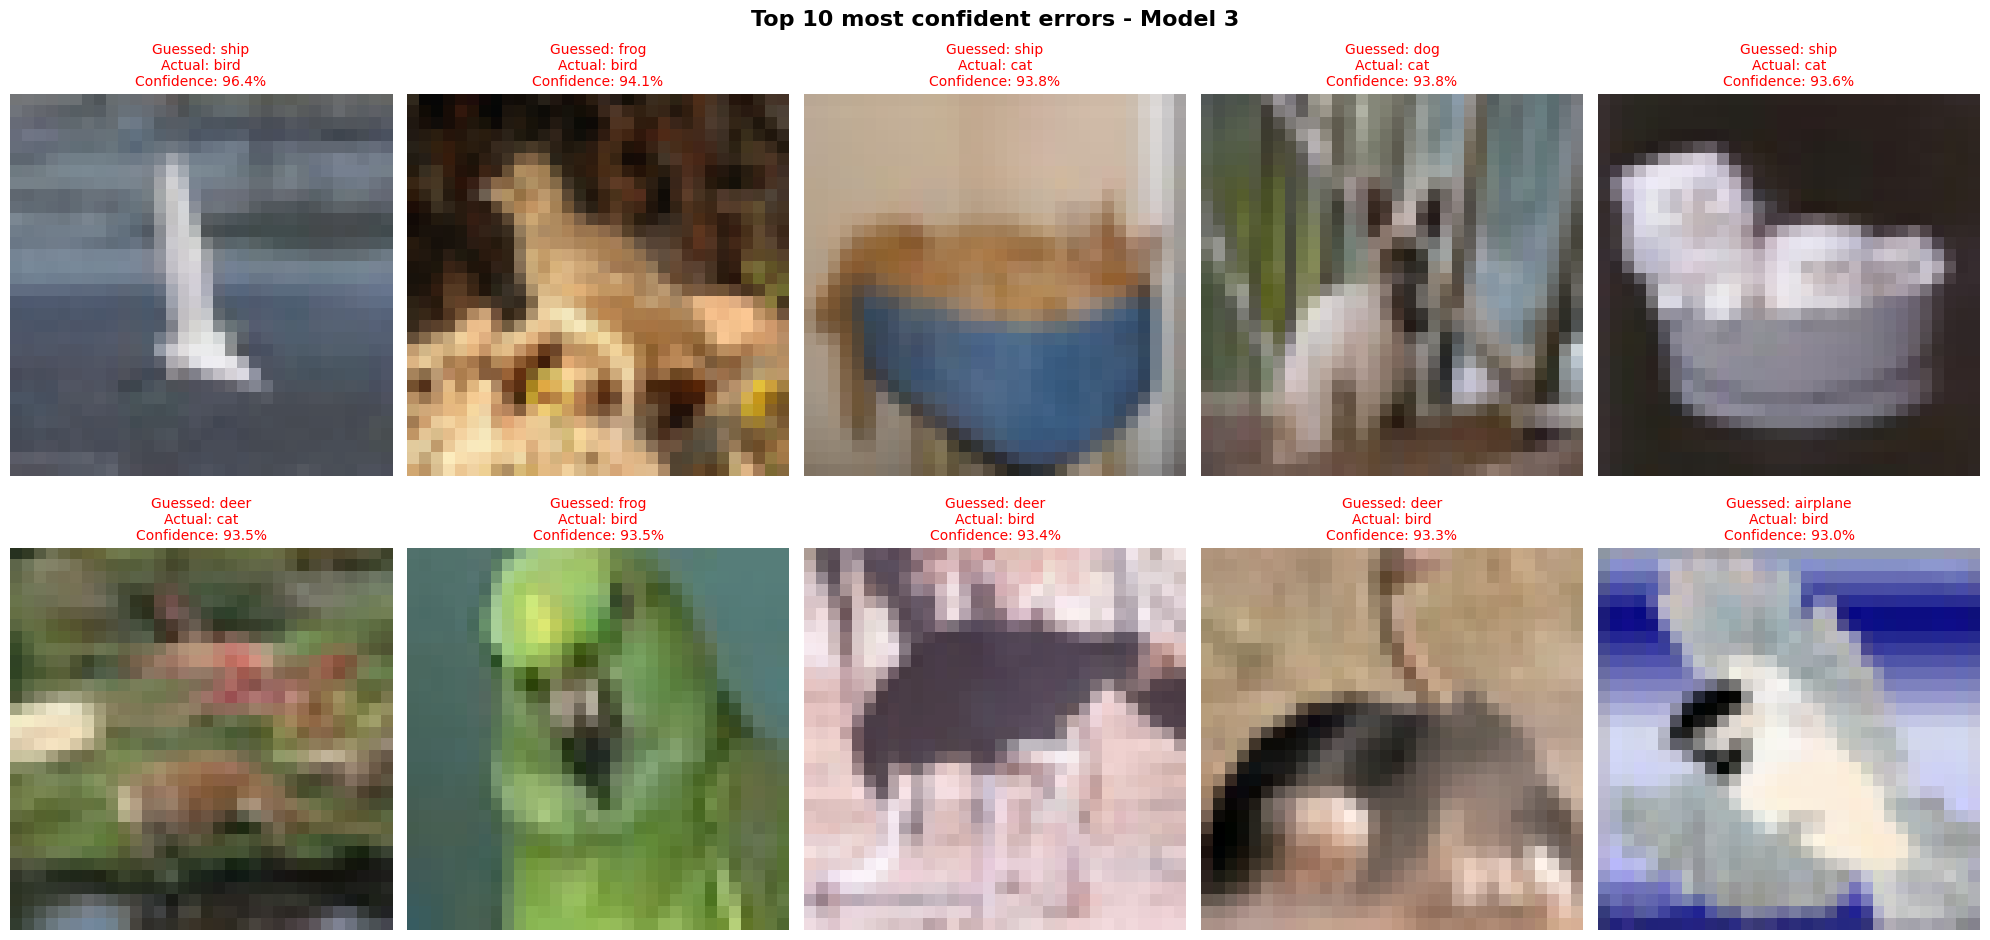

In [ ]:
def plot_confident_errors(model, test_loader, class_names, num_images=10):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    all_errors = []
    
    print("Analyzing confident errors...")
    with torch.no_grad():
        for images, labels in test_loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            
            # transform outputs to probabilities (0.0 - 1.0)
            probabilities = torch.softmax(outputs, dim=1)
            conf, preds = torch.max(probabilities, 1)
            
            # Find where predictions do not match the actual labels
            mask = (preds != labels.to(device))
            
            # Save info for misclassified images
            if mask.any():
                batch_errors = zip(
                    images[mask.cpu()], 
                    labels[mask.cpu()].numpy(), 
                    preds[mask.cpu()].cpu().numpy(), 
                    conf[mask.cpu()].cpu().numpy()
                )
                all_errors.extend(list(batch_errors))

    # Sort errors based on confidence (highest first)
    all_errors.sort(key=lambda x: x[3], reverse=True)

    # Plot the most confident errors
    plt.figure(figsize=(20, 10))
    for i in range(min(num_images, len(all_errors))):
        img_tensor, actual, pred, confidence = all_errors[i]
        
        plt.subplot(2, 5, i + 1)
        
        # Denormalize for correct display 
        img = img_tensor.numpy().transpose((1, 2, 0))
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2470, 0.2435, 0.2616])
        img = std * img + mean
        img = np.clip(img, 0, 1) 
        
        plt.imshow(img)
        plt.title(f"Guessed: {class_names[pred]}\n"
                  f"Actual: {class_names[actual]}\n"
                  f"Confidence: {confidence*100:.1f}%", 
                  color='red', fontsize=10)
        plt.axis('off')
    
    plt.suptitle(f"Top {num_images} most confident errors - Model 3", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confident_errors(model3, test_dataloader, test_base.classes, num_images=10)

In [22]:
from sklearn.metrics import classification_report

device = torch.device('mps' if torch.mps.is_available() else 'cpu')
model3.to(device)

def show_classification_report(model, test_loader, class_names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            outputs = model(imgs.to(device))
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            
    print(classification_report(y_true, y_pred, target_names=class_names))

show_classification_report(model3, test_dataloader, test_base.classes)

              precision    recall  f1-score   support

    airplane       0.91      0.93      0.92      1000
  automobile       0.96      0.97      0.96      1000
        bird       0.92      0.87      0.89      1000
         cat       0.85      0.78      0.81      1000
        deer       0.90      0.93      0.91      1000
         dog       0.86      0.88      0.87      1000
        frog       0.92      0.96      0.94      1000
       horse       0.94      0.95      0.95      1000
        ship       0.96      0.95      0.95      1000
       truck       0.93      0.96      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



### **Error Analys**

**Övergripande prestanda:**
- Test Accuracy: 91.59%
- Bästa klasser(Recall): Automobile (97%), Frog (96%), Truck(96%), Horse(95%) och Ship (95%)
- Svagaste klasser(Recall): Cat (78%), Bird (87%) och Dog (88%)

Modellen har generellt svårare med djurklasser än fordon, särskilt hund vs katt. Konfusionsmatrisen visar att modellen missklassificerat 99 kattbilder som hund och 67 hundbilder som katt (totalt 166 fel mellan dessa två). Detta beror på att hund och katt delar många liknande särdrag som öron, nos och päls. Med den låga upplösningen (32×32 pixlar) blir det svårt att separera för modellen men även för mig. 

Däremot har modellen mycket lättare för fordon - Automobile, Ship och Truck har alla en precision på 96% eller högre. Detta beror på att de har tydliga geometriska former, hjul och fönster, vilket gör det lättare för konvolutionslagren att extrahera unika mönster.

Modellen uppvisar även en viss förvirring mellan Airplane, Ship och Bird. Exempelvis ser vi att 21 flygplan misstogs för skepp och 19 fåglar misstogs för flygplan. Detta beror sannolikt på att dessa objekt ofta fotograferas mot en liknande blå bakgrund (himmel eller vatten) och har liknande silhuetter, såsom vingar kontra segel eller skrov. En annan intressant felkälla är att 25 skepp klassificerades som flygplan, vilket ytterligare stärker teorin om att den blåa bakgrundsmiljön spelar en stor roll för modellens gissningar.

Exempelbilderna på modellens missar (Top 10 confident errors) bekräftar detta. Vi ser bland annat en fågel som modellen med 96,4% säkerhet tror är ett skepp, och en vit katt i en korg som klassas som ett skepp (93,6%), förmodligen på grund av korgens form och den ljusa färgen. Vissa bilder är så pixlade att de är svåra även för en människa att identifiera. Det är tydligt att modellen ibland "luras" av bakgrundsbrus eller ovanliga vinklar.

**Förbättringsmöjligheter:**
För att komma över 95% skulle jag kunna:
- Använda pretrained modeller (ResNet/EfficientNet) 
- Införa class weights eller focal loss för att fokusera mer på cat/dog-problemet
- Mer aggressiv data augmentation, speciellt för djurklasser
- Ensemble av flera modeller

**Slutsats:**
Att få nästan 92% test accuracy på 30 epochs är ett mycket bra resultat. AArkitekturen i Modell 3 är en logisk vidareutveckling av Modell 1 och 2, och resultaten visar tydligt hur ett djupare och mer komplext nätverk ger direkt avkastning i prestanda:

- Modell 1: ~77%

- Modell 2: ~88%

- Modell 3: ~92%


---
## **Pretrained model**⭐️

In [ ]:
from torchvision import models

# Transform for ResNet-50 (ImageNet-standard)
# Scale up to 224x224 for ResNet to utilize its pretrained filters optimally.
train_transform_pt = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # extra augmentation to help reach >95% accuracy
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Same for validation and test (no augmentation here, just resize and normalization)
test_transform_pt = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Create Datasets and Loaders (Using your existing train_base and test_base)
# Split 45k for training and 5k for validation
indices = list(range(50000))
train_idx, val_idx = indices[:45000], indices[45000:]

train_data = ApplyTransform(train_base, train_idx, train_transform_pt)
val_data = ApplyTransform(train_base, val_idx, test_transform_pt)
test_data = ApplyTransform(test_base, None, test_transform_pt)


train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:

# Load pre-trained ResNet-50 model and use pretrained weights from ImageNet
model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Change the final fully connected layer to output 10 classes 
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, 10)


# AdamW with label smoothing and weight decay to help with generalization and potentially reach >95% accuracy faster.
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_resnet.parameters(), lr=1e-4, weight_decay=1e-2)

num_epochs = 5 # Don't need many epochs with a pretrained model 
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=1e-3, 
    steps_per_epoch=len(train_dataloader), 
    epochs=num_epochs
)



In [ ]:
# Using my existing train_model function to train ResNet-50 with transfer learning
print("Tränar ResNet-50 med Transfer Learning...")
train_losses, val_losses, val_accuracies = train_model(
    model_resnet, 
    train_dataloader, 
    val_dataloader, 
    criterion, 
    optimizer, 
    scheduler, 
    epochs=num_epochs
)



Tränar ResNet-50 med Transfer Learning...
Epoch [1/5] - Train Loss: 0.9308, Val Loss: 1.0783, Val Acc: 75.02% - LR: 0.000761
Epoch [2/5] - Train Loss: 0.9145, Val Loss: 0.8384, Val Acc: 87.34% - LR: 0.000950
Epoch [3/5] - Train Loss: 0.7804, Val Loss: 0.7635, Val Acc: 89.58% - LR: 0.000611
Epoch [4/5] - Train Loss: 0.6648, Val Loss: 0.6302, Val Acc: 95.02% - LR: 0.000188
Epoch [5/5] - Train Loss: 0.5808, Val Loss: 0.6074, Val Acc: 95.80% - LR: 0.000000
Training completed!


In [ ]:
# Final evaluation on the test (only useed once at the end)
print("\n--- Slutgiltig utvärdering på Test-setet ---")
model_resnet.eval()
test_correct = 0
test_total = 0
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f'Slutgiltig Test Accuracy: {100 * test_correct / test_total:.2f}%')


--- Slutgiltig utvärdering på Test-setet ---
Slutgiltig Test Accuracy: 95.44%


---
## **Ville bara plotta på kul😁**

In [35]:
def plot_deeper_feature_maps(model, image, block_idx):
    model.eval()
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    
    # Create a sub-model up to the specified block index
    layers = list(model.features.children())[:block_idx+1]
    feature_extractor = nn.Sequential(*layers).to(device)
    
    with torch.no_grad():
        f_maps = feature_extractor(image.to(device).unsqueeze(0))
    
    # Plot the first 16 feature maps 
    plt.figure(figsize=(15, 15))
    channels = min(f_maps.shape[1], 16) 
    for i in range(channels):
        plt.subplot(4, 4, i+1)
        # Use 'viridis' colormap for better visibility
        plt.imshow(f_maps[0, i].cpu(), cmap='viridis') 
        plt.axis('off')
    
    plt.suptitle(f"Feature Maps från lager index {block_idx}", fontsize=20)
    plt.show()



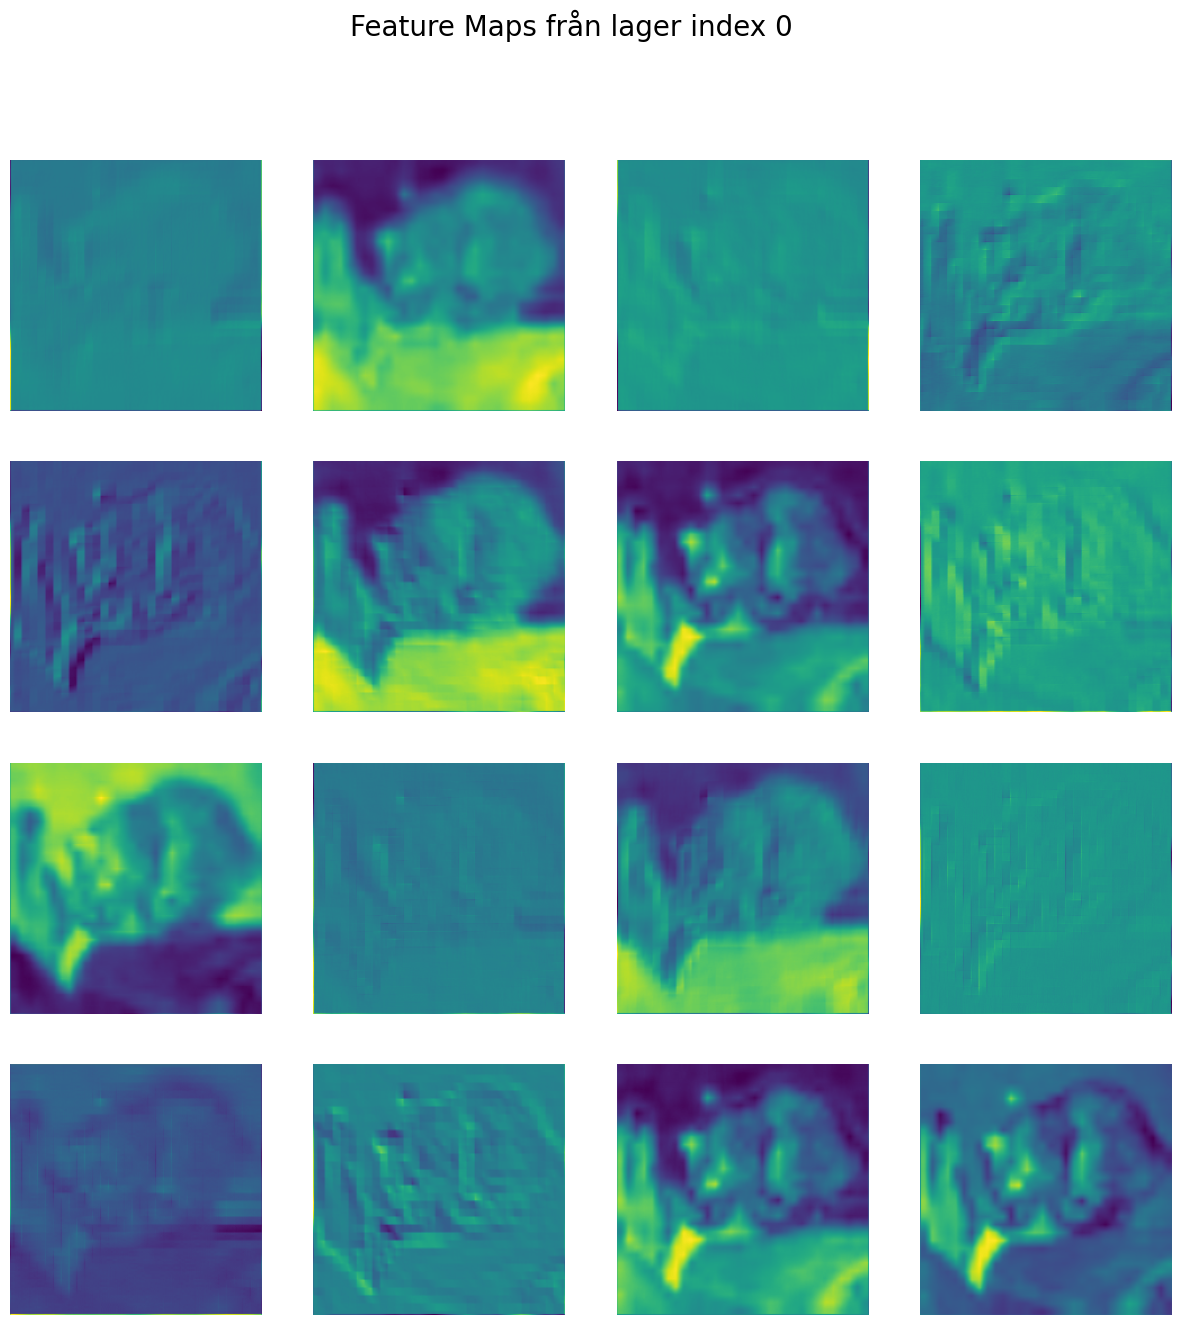

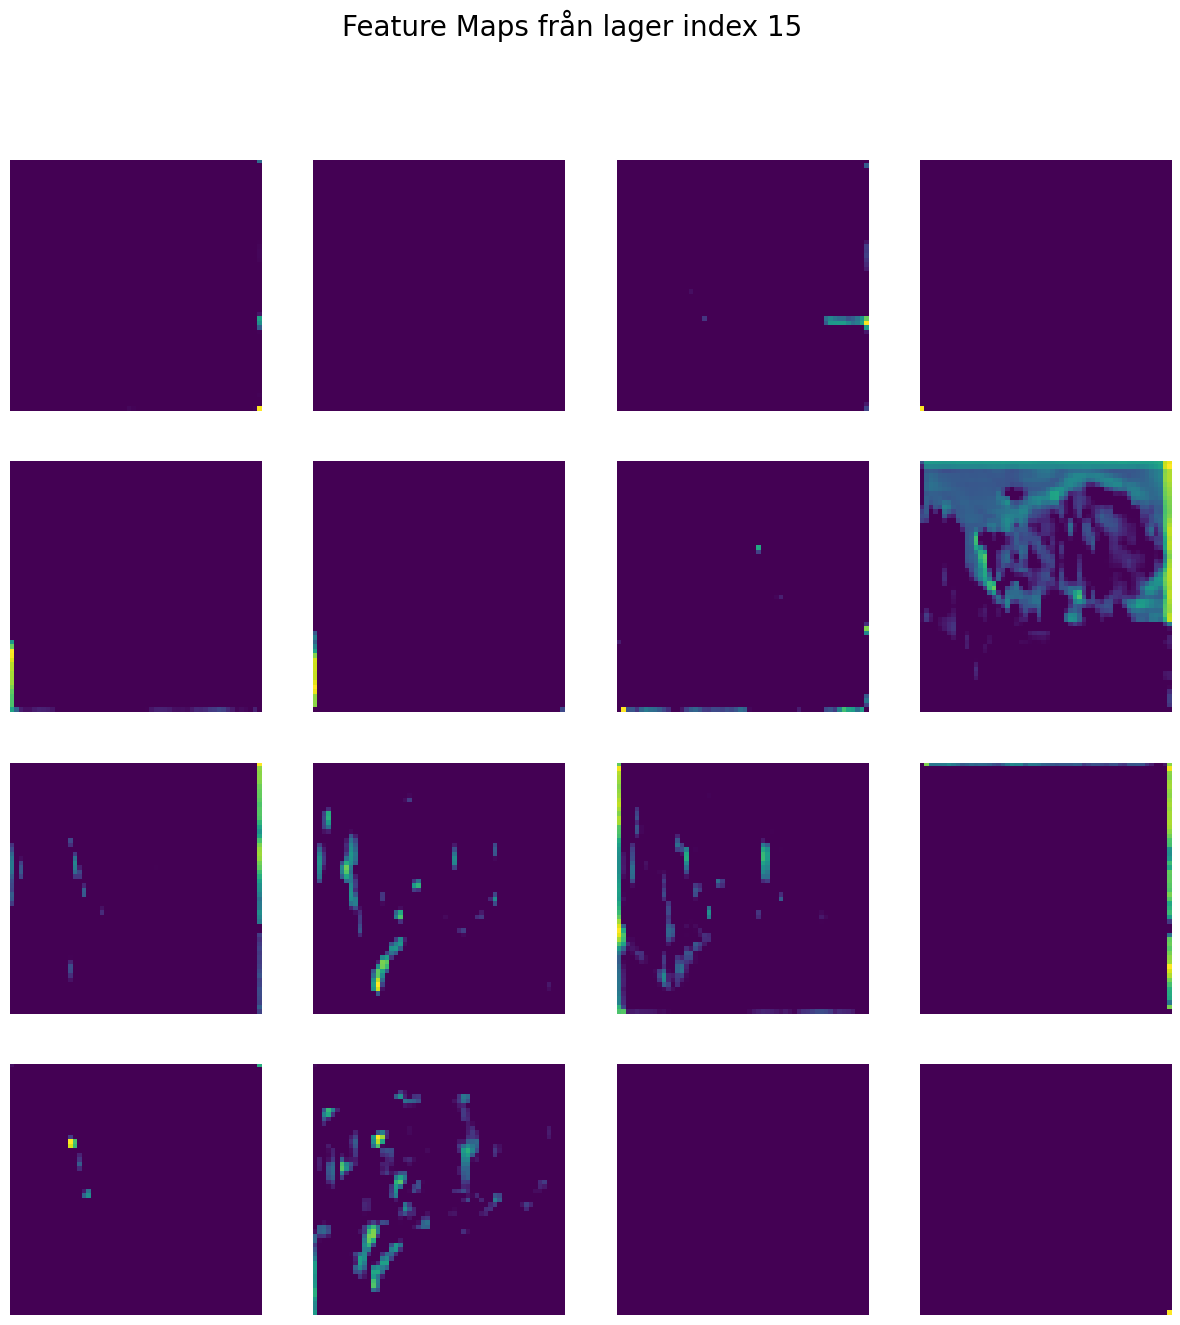

In [36]:
# Get a sample image from the test set
sample_imgs, sample_labels = next(iter(test_dataloader))

# Choose the first image in the batch (shape: [C, H, W])
sample_img = sample_imgs[0]

# Test to view feature maps from the first convolutional layer
plot_deeper_feature_maps(model3, sample_img, 0)

# Test to view feature maps from a deeper layer
plot_deeper_feature_maps(model3, sample_img, 15)